# 02 — IDRiD Data Exploration

**Goal:** Understand the IDRiD dataset before merging with APTOS.

Key questions:
- How does the class distribution compare to APTOS?
- Are image sizes compatible?
- What do the extra columns (macular edema, captions) look like?
- Are there any mismatches between CSV and actual image files?

---

## 📦 1. Imports & Config

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from pathlib import Path
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# ── Paths ─────────────────────────────────────────────────────────────────────
BASE_DIR        = Path('../data/raw').resolve()
APTOS_DIR       = BASE_DIR / 'aptos'
IDRID_DIR       = BASE_DIR / 'idrid'
IDRID_TRAIN_IMG = IDRID_DIR / 'train_images'
IDRID_TEST_IMG  = IDRID_DIR / 'test_images'
IDRID_TRAIN_CSV = IDRID_DIR / 'train_labels.csv'
IDRID_TEST_CSV  = IDRID_DIR / 'test_labels.csv'
APTOS_CSV       = APTOS_DIR / 'train.csv'
RESULTS_DIR     = Path('../results').resolve()
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

GRADE_LABELS = {
    0: 'No DR',
    1: 'Mild',
    2: 'Moderate',
    3: 'Severe',
    4: 'Proliferative'
}

# Sanity checks
for p in [IDRID_TRAIN_IMG, IDRID_TEST_IMG, IDRID_TRAIN_CSV, IDRID_TEST_CSV, APTOS_CSV]:
    print(f'  {"✅" if p.exists() else "❌"}  {p}')

  ✅  D:\projects\diabetic-retinopathy-detection\data\raw\idrid\train_images
  ✅  D:\projects\diabetic-retinopathy-detection\data\raw\idrid\test_images
  ✅  D:\projects\diabetic-retinopathy-detection\data\raw\idrid\train_labels.csv
  ✅  D:\projects\diabetic-retinopathy-detection\data\raw\idrid\test_labels.csv
  ✅  D:\projects\diabetic-retinopathy-detection\data\raw\aptos\train.csv


---
## 📂 2. Load CSVs

In [2]:
# Load IDRiD
train_df = pd.read_csv(IDRID_TRAIN_CSV)
test_df  = pd.read_csv(IDRID_TEST_CSV)

# Standardise column names
train_df = train_df.rename(columns={
    'Image name'           : 'id_code',
    'Retinopathy grade'    : 'diagnosis',
    'Risk of macular edema': 'macular_edema',
    'Captions'             : 'caption'
})
test_df = test_df.rename(columns={
    'Image name'           : 'id_code',
    'Retinopathy grade'    : 'diagnosis',
    'Risk of macular edema': 'macular_edema',
    'Captions'             : 'caption'
})

# ── Filter to main fundus images only (no overlay files) ─────────────────────
def get_main_images(img_dir: Path) -> set:
    """Returns set of image IDs that are main fundus photos (no suffix like _L14)."""
    return {
        f.stem  # filename without extension
        for f in img_dir.glob('*.jpg')
        if len(f.stem.split('_')) == 2   # IDRiD_001 → 2 parts only
    }

train_valid_ids = get_main_images(IDRID_TRAIN_IMG)
test_valid_ids  = get_main_images(IDRID_TEST_IMG)

train_df = train_df[train_df['id_code'].isin(train_valid_ids)].reset_index(drop=True)
test_df  = test_df[test_df['id_code'].isin(test_valid_ids)].reset_index(drop=True)

# Attach filepaths
train_df['filepath'] = train_df['id_code'].apply(lambda x: IDRID_TRAIN_IMG / f'{x}.jpg')
test_df['filepath']  = test_df['id_code'].apply(lambda x: IDRID_TEST_IMG  / f'{x}.jpg')
train_df['grade_label'] = train_df['diagnosis'].map(GRADE_LABELS)
test_df['grade_label']  = test_df['diagnosis'].map(GRADE_LABELS)

print(f'IDRiD train (usable) : {len(train_df)}')
print(f'IDRiD test  (usable) : {len(test_df)}')
print(f'Total IDRiD          : {len(train_df) + len(test_df)}')
print()
train_df.head()

IDRiD train (usable) : 413
IDRiD test  (usable) : 103
Total IDRiD          : 516



,id_code,diagnosis,macular_edema,class,caption,filepath,grade_label
0,IDRiD_001,3,2,Clinically_Significant_Macular_Edema,Severe diabetic retinopathy with extensive ret...,D:\projects\diabetic-retinopathy-detection\dat...,Severe
1,IDRiD_002,3,2,Clinically_Significant_Macular_Edema,Severe nonproliferative diabetic retinopathy w...,D:\projects\diabetic-retinopathy-detection\dat...,Severe
2,IDRiD_003,2,2,Clinically_Significant_Macular_Edema,Advanced nonproliferative diabetic changes wit...,D:\projects\diabetic-retinopathy-detection\dat...,Moderate
3,IDRiD_004,3,2,Clinically_Significant_Macular_Edema,Severe diabetic retinopathy with extensive ret...,D:\projects\diabetic-retinopathy-detection\dat...,Severe
4,IDRiD_005,4,0,Severe_PDR,Fundoscopic examination reveals proliferative ...,D:\projects\diabetic-retinopathy-detection\dat...,Proliferative


---
## 🔢 3. Class Distribution — IDRiD vs APTOS

In [3]:
# Combined IDRiD
idrid_all = pd.concat([train_df, test_df], ignore_index=True)

# APTOS
aptos_df  = pd.read_csv(APTOS_CSV)

idrid_counts = idrid_all['diagnosis'].value_counts().sort_index()
aptos_counts = aptos_df['diagnosis'].value_counts().sort_index()

print('Grade distribution comparison:')
print(f'\n{"Grade":<25} {"IDRiD":>8} {"IDRiD%":>8} {"APTOS":>8} {"APTOS%":>8}')
print('-' * 55)
for g in range(5):
    ic = idrid_counts.get(g, 0)
    ac = aptos_counts.get(g, 0)
    ip = ic / len(idrid_all) * 100
    ap = ac / len(aptos_df)  * 100
    print(f'{GRADE_LABELS[g]:<25} {ic:>8} {ip:>7.1f}% {ac:>8} {ap:>7.1f}%')

Grade distribution comparison:

Grade                        IDRiD   IDRiD%    APTOS   APTOS%
-------------------------------------------------------
No DR                          168    32.6%     1805    49.3%
Mild                            25     4.8%      370    10.1%
Moderate                       168    32.6%      999    27.3%
Severe                          93    18.0%      193     5.3%
Proliferative                   62    12.0%      295     8.1%


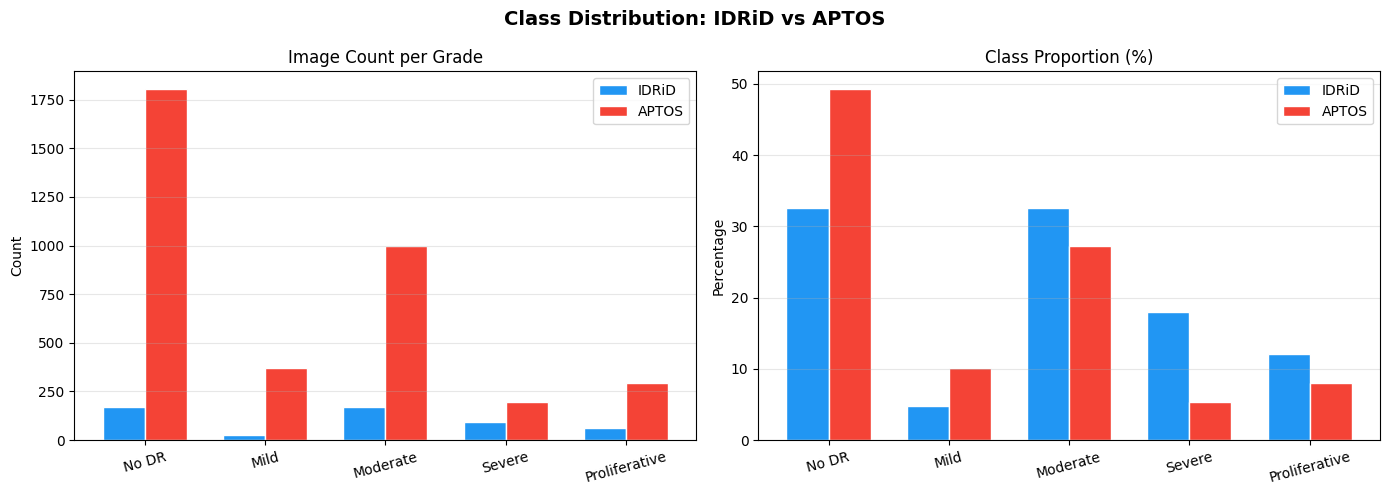

Saved → results/idrid_vs_aptos_distribution.png


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Class Distribution: IDRiD vs APTOS', fontsize=14, fontweight='bold')

labels = [GRADE_LABELS[i] for i in range(5)]
x      = np.arange(5)
width  = 0.35
colors = ['#2196F3', '#F44336']

# ── Side by side bar ──────────────────────────────────────────────────────────
b1 = axes[0].bar(x - width/2, [idrid_counts.get(i,0) for i in range(5)],
                 width, label='IDRiD', color=colors[0], edgecolor='white')
b2 = axes[0].bar(x + width/2, [aptos_counts.get(i,0) for i in range(5)],
                 width, label='APTOS', color=colors[1], edgecolor='white')
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels, rotation=15)
axes[0].set_title('Image Count per Grade')
axes[0].set_ylabel('Count')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# ── Percentage comparison ─────────────────────────────────────────────────────
idrid_pct = [idrid_counts.get(i,0)/len(idrid_all)*100 for i in range(5)]
aptos_pct = [aptos_counts.get(i,0)/len(aptos_df)*100  for i in range(5)]
axes[1].bar(x - width/2, idrid_pct, width, label='IDRiD', color=colors[0], edgecolor='white')
axes[1].bar(x + width/2, aptos_pct, width, label='APTOS', color=colors[1], edgecolor='white')
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels, rotation=15)
axes[1].set_title('Class Proportion (%)')
axes[1].set_ylabel('Percentage')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'idrid_vs_aptos_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → results/idrid_vs_aptos_distribution.png')

---
## 🖼️ 4. Sample IDRiD Images per Grade

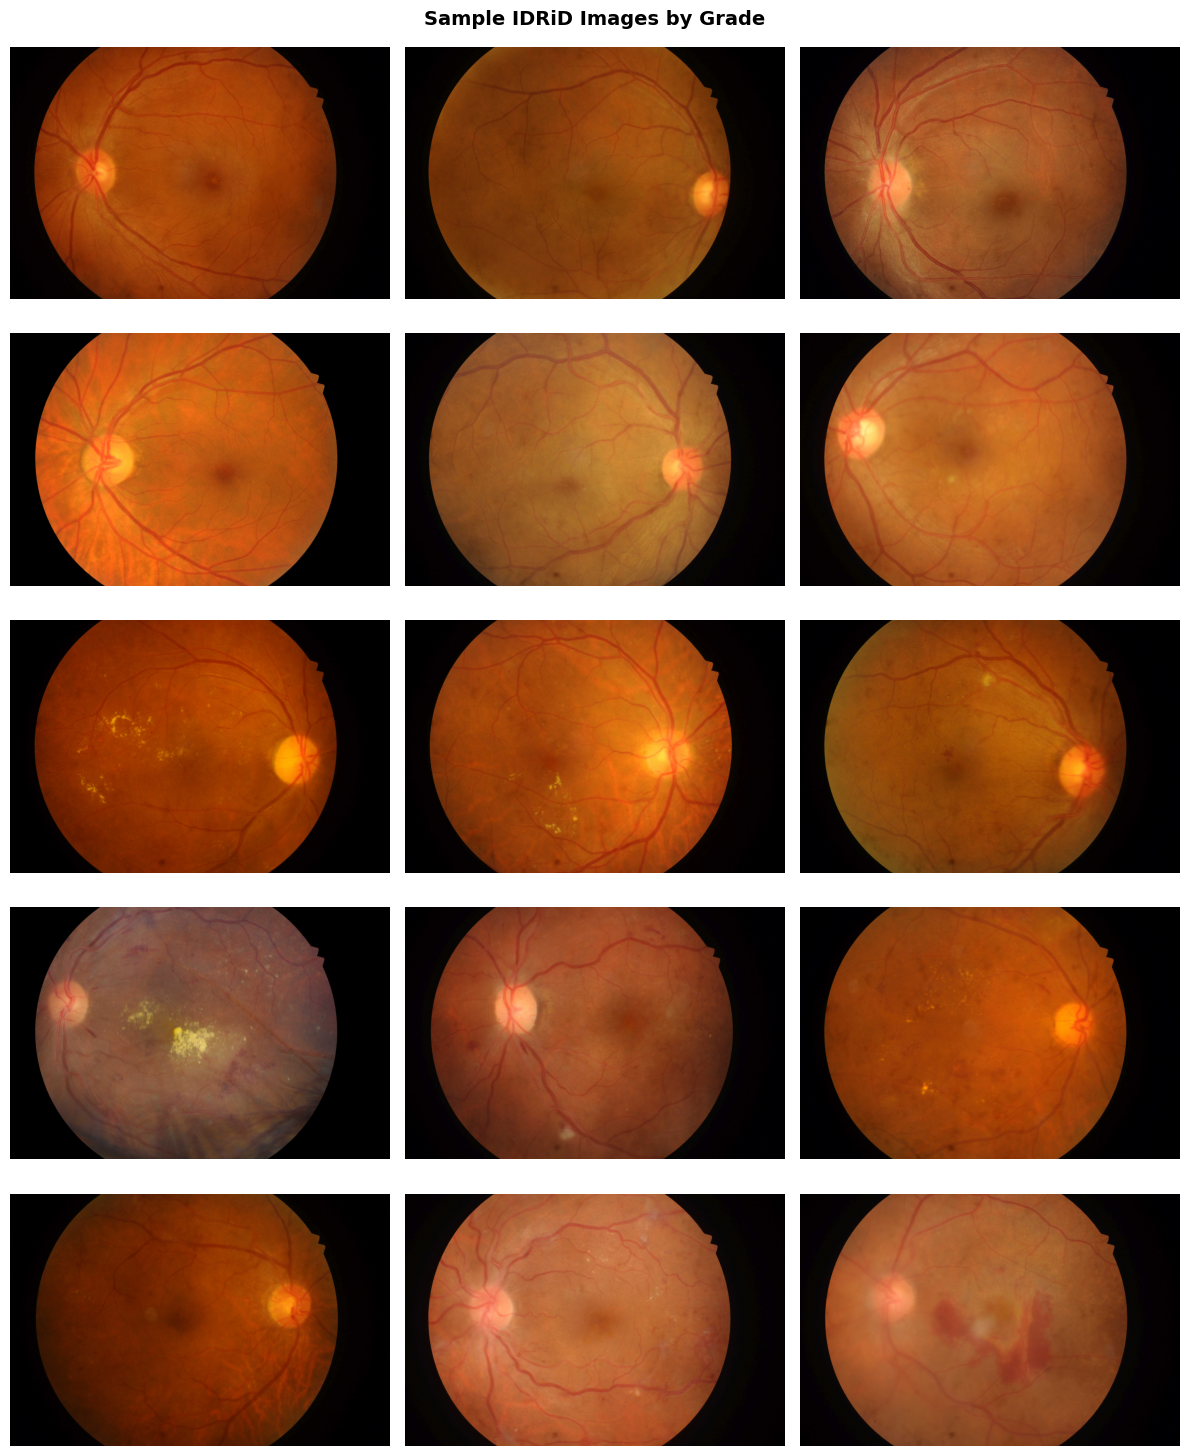

Saved → results/idrid_sample_images.png


In [6]:
N = 3
grades_present = sorted(idrid_all['diagnosis'].unique())

fig, axes = plt.subplots(len(grades_present), N, figsize=(N*4, len(grades_present)*3))
fig.suptitle('Sample IDRiD Images by Grade', fontsize=14, fontweight='bold')

for row, grade in enumerate(grades_present):
    grade_df = idrid_all[idrid_all['diagnosis'] == grade]
    samples  = grade_df.sample(min(N, len(grade_df)), random_state=42)
    for col in range(N):
        ax = axes[row][col] if len(grades_present) > 1 else axes[col]
        if col < len(samples):
            try:
                img = Image.open(str(samples.iloc[col]['filepath'])).convert('RGB')
                ax.imshow(np.array(img))
            except Exception as e:
                ax.text(0.5, 0.5, str(e), ha='center', va='center',
                        transform=ax.transAxes, fontsize=6, color='red')
        ax.axis('off')
        if col == 0:
            ax.set_ylabel(f'Grade {grade}\n{GRADE_LABELS[grade]}',
                          fontsize=10, fontweight='bold',
                          rotation=0, labelpad=70, va='center')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'idrid_sample_images.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → results/idrid_sample_images.png')

---
## 📐 5. Image Resolution Check

In [7]:
print('Checking IDRiD image resolutions...')
widths, heights = [], []

for fp in tqdm(idrid_all['filepath']):
    try:
        with Image.open(str(fp)) as img:
            widths.append(img.width)
            heights.append(img.height)
    except Exception:
        widths.append(None)
        heights.append(None)

idrid_all['width']  = widths
idrid_all['height'] = heights
valid = idrid_all[idrid_all['width'].notna()]

print(f'\nIDRiD resolutions:')
print(f'  Width  — min: {valid.width.min():.0f}, max: {valid.width.max():.0f}, mean: {valid.width.mean():.0f}')
print(f'  Height — min: {valid.height.min():.0f}, max: {valid.height.max():.0f}, mean: {valid.height.mean():.0f}')
print(f'\nAPTOS resolutions (from notebook 01):')
print(f'  Width  — min: 474, max: 4288, mean: 2015')
print(f'  Height — min: 358, max: 2848, mean: 1527')
print(f'\n✅ Both will be resized to 224×224 during preprocessing — compatible')

Checking IDRiD image resolutions...


100%|██████████| 516/516 [00:22<00:00, 22.89it/s]



IDRiD resolutions:
  Width  — min: 4288, max: 4288, mean: 4288
  Height — min: 2848, max: 2848, mean: 2848

APTOS resolutions (from notebook 01):
  Width  — min: 474, max: 4288, mean: 2015
  Height — min: 358, max: 2848, mean: 1527

✅ Both will be resized to 224×224 during preprocessing — compatible


---
## 💬 6. Captions & Macular Edema (IDRiD Exclusive)

In [8]:
# Macular edema distribution
print('Macular Edema Risk Distribution:')
edema_labels = {0: 'No Risk', 1: 'Moderate Risk', 2: 'High Risk'}
edema_counts = idrid_all['macular_edema'].value_counts().sort_index()
for k, v in edema_counts.items():
    print(f'  {edema_labels[k]:<20}: {v} ({v/len(idrid_all)*100:.1f}%)')

print()

# Sample captions per grade
print('Sample Captions by Grade:')
print('─' * 60)
for grade in range(5):
    subset = idrid_all[idrid_all['diagnosis'] == grade]
    if len(subset) == 0:
        continue
    sample_caption = subset.iloc[0]['caption']
    print(f'Grade {grade} ({GRADE_LABELS[grade]}):')
    print(f'  "{sample_caption[:120]}..."')
    print()

Macular Edema Risk Distribution:
  No Risk             : 222 (43.0%)
  Moderate Risk       : 51 (9.9%)
  High Risk           : 243 (47.1%)

Sample Captions by Grade:
────────────────────────────────────────────────────────────
Grade 0 (No DR):
  "Fundoscopic evaluation reveals no diabetic retinal changes with preserved neurosensory retina and normal macular contour..."

Grade 1 (Mild):
  "Fundoscopic examination reveals mild diabetic retinopathy with minimal retinal vascular changes and no macular edema for..."

Grade 2 (Moderate):
  "Advanced nonproliferative diabetic changes with hemorrhages and exudates showing moderate risk for macular edema develop..."

Grade 3 (Severe):
  "Severe diabetic retinopathy with extensive retinal lesions and moderate predisposing factors for macular involvement. Re..."

Grade 4 (Proliferative):
  "Fundoscopic examination reveals proliferative diabetic retinopathy with neovascularization and fibrovascular tissue but ..."



---
## 🔗 7. Combined Dataset Preview

In [11]:
# What the merged dataset will look like
combined_counts = {}
for g in range(5):
    a = aptos_counts.get(g, 0)
    i = idrid_counts.get(g, 0)
    combined_counts[g] = a + i

total_combined = sum(combined_counts.values())

print('Combined Dataset Preview (APTOS + IDRiD):')
print(f'\n{"Grade":<25} {"APTOS":>8} {"IDRiD":>8} {"Combined":>10} {"% total":>8}')
print('─' * 63)
for g in range(5):
    a  = aptos_counts.get(g, 0)
    i  = idrid_counts.get(g, 0)
    c  = combined_counts[g]
    pct = c / total_combined * 100
    print(f'{GRADE_LABELS[g]:<25} {a:>8} {i:>8} {c:>10} {pct:>7.1f}%')
print('─' * 63)
print(f'{"TOTAL":<25} {len(aptos_df):>8} {len(idrid_all):>8} {total_combined:>10}')

print(f'\nIncrease over APTOS alone: +{len(idrid_all)} images (+{len(idrid_all)/len(aptos_df)*100:.1f}%)')

Combined Dataset Preview (APTOS + IDRiD):

Grade                        APTOS    IDRiD   Combined  % total
───────────────────────────────────────────────────────────────
No DR                         1805      168       1973    47.2%
Mild                           370       25        395     9.5%
Moderate                       999      168       1167    27.9%
Severe                         193       93        286     6.8%
Proliferative                  295       62        357     8.5%
───────────────────────────────────────────────────────────────
TOTAL                         3662      516       4178

Increase over APTOS alone: +516 images (+14.1%)


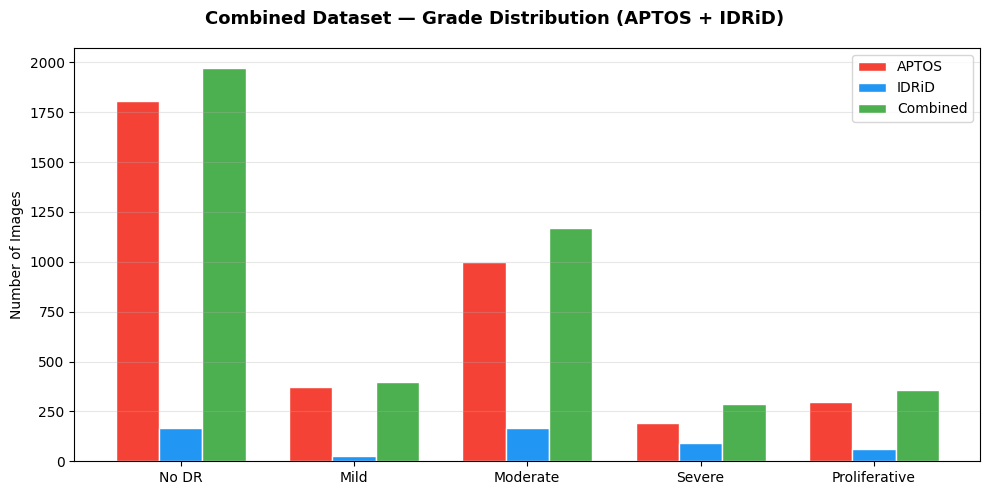

Saved → results/combined_distribution.png


In [12]:
# Save the combined distribution chart
fig, ax = plt.subplots(figsize=(10, 5))
fig.suptitle('Combined Dataset — Grade Distribution (APTOS + IDRiD)',
             fontsize=13, fontweight='bold')

labels  = [GRADE_LABELS[i] for i in range(5)]
x       = np.arange(5)
width   = 0.25
colors  = ['#F44336', '#2196F3', '#4CAF50']

ax.bar(x - width, [aptos_counts.get(i,0) for i in range(5)],
       width, label='APTOS', color=colors[0], edgecolor='white')
ax.bar(x,         [idrid_counts.get(i,0) for i in range(5)],
       width, label='IDRiD', color=colors[1], edgecolor='white')
ax.bar(x + width, list(combined_counts.values()),
       width, label='Combined', color=colors[2], edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel('Number of Images')
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'combined_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → results/combined_distribution.png')

---
## ✅ 8. Summary

In [13]:
print('=' * 52)
print('  IDRiD EXPLORATION SUMMARY')
print('=' * 52)
print(f'  Usable IDRiD images   : {len(idrid_all)}')
print(f'    Train               : {len(train_df)}')
print(f'    Test                : {len(test_df)}')
print(f'  Image format          : .jpg (APTOS is .png)')
print(f'  Extra columns         : macular_edema, caption')
print(f'  Compatible grades     : ✅ 0–4 same as APTOS')
print(f'  Compatible resolution : ✅ will resize to 224×224')
print()
print(f'  Combined total        : {total_combined} images')
print(f'  Improvement over APTOS: +{len(idrid_all)/len(aptos_df)*100:.1f}% more data')
print()
print('  Next steps:')
print('    1. Preprocess IDRiD images (CLAHE + resize)')
print('    2. Merge into unified dataset_loader.py')
print('    3. Retrain model')
print('=' * 52)

  IDRiD EXPLORATION SUMMARY
  Usable IDRiD images   : 516
    Train               : 413
    Test                : 103
  Image format          : .jpg (APTOS is .png)
  Extra columns         : macular_edema, caption
  Compatible grades     : ✅ 0–4 same as APTOS
  Compatible resolution : ✅ will resize to 224×224

  Combined total        : 4178 images
  Improvement over APTOS: +14.1% more data

  Next steps:
    1. Preprocess IDRiD images (CLAHE + resize)
    2. Merge into unified dataset_loader.py
    3. Retrain model
